# My Spotify Listening Analysis
### A personal data analysis project using the Spotify API

Analyzing my own Spotify listening history to uncover patterns in:
- My top artists and tracks
- What time of day I listen most
- How my taste has shifted over time

**Tools used:** Python, Spotipy, Pandas, Matplotlib

In [1]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from dotenv import load_dotenv
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Load credentials
load_dotenv()

# Authenticate
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=os.getenv("SPOTIPY_CLIENT_ID"),
    client_secret=os.getenv("SPOTIPY_CLIENT_SECRET"),
    redirect_uri=os.getenv("SPOTIPY_REDIRECT_URI"),
    scope="user-top-read user-read-recently-played"
))

user = sp.current_user()
print(f"Connected as: {user['display_name']}")

Connected as: brandon


## 1. Top Artists & Tracks
Pulling my all-time top 10 artists and tracks from the Spotify API.

In [4]:
print("\n--- Your Top 10 Artists ---\n")
top_artists = sp.current_user_top_artists(limit=10, time_range="long_term")


for i, artist in enumerate(top_artists['items'], 1):
    print(f"{i}. {artist['name']}")

# Top 10 tracks of all time
print("\n--- Your Top 10 Tracks ---\n")
top_tracks = sp.current_user_top_tracks(limit=10, time_range="long_term")

for i, track in enumerate(top_tracks['items'], 1):
    print(f"{i}. {track['name']} by {track['artists'][0]['name']}")



--- Your Top 10 Artists ---

1. Drake
2. J. Cole
3. Travis Scott
4. Future
5. All Time Low
6. Green Day
7. Lil Wayne
8. Kanye West
9. A$AP Rocky
10. Neck Deep

--- Your Top 10 Tracks ---

1. One Last Breath by Creed
2. Fancy by Drake
3. Time by Hans Zimmer
4. You Were Right by RÜFÜS DU SOL
5. Over My Dead Body by Drake
6. Come Thru by Drake
7. DtMF by Bad Bunny
8. Too Deep for the Intro by J. Cole
9. 9 by Drake
10. U With Me? by Drake


## 2. Listening by Hour of Day
Analyzing my last 50 played tracks to find what time of day I listen to music most.
Note: Times are in UTC — subtract 4 hours for Eastern Time.


--- Recent Listening --

1. RÜFÜS DU SOL, played at: 2026-06-29T15:35:11.425Z
2. Furacão 2000, played at: 2026-06-29T14:54:22.202Z
3. Mac Miller, played at: 2026-06-29T14:52:08.408Z
4. Drake, played at: 2026-06-29T14:48:59.342Z
5. Kid Cudi, played at: 2026-06-29T14:43:46.806Z
6. Drake, played at: 2026-06-29T14:05:06.676Z
7. mgk, played at: 2026-06-29T12:47:34.091Z
8. State Champs, played at: 2026-06-29T12:44:55.280Z
9. Chris Brown, played at: 2026-06-29T12:39:22.274Z
10. Neck Deep, played at: 2026-06-29T12:35:27.476Z
11. girlfriends, played at: 2026-06-29T12:32:14.972Z
12. Lil Wayne, played at: 2026-06-29T12:29:24.778Z
13. J. Cole, played at: 2026-06-29T02:21:40.677Z
14. J. Cole, played at: 2026-06-28T23:26:37.840Z
15. Point North, played at: 2026-06-28T23:23:12.344Z
16. Childish Gambino, played at: 2026-06-28T23:20:03.938Z
17. J. Cole, played at: 2026-06-28T23:14:43.844Z
18. Mac Miller, played at: 2026-06-28T23:07:08.529Z
19. Pierce The Veil, played at: 2026-06-28T23:00:57.537Z
20. O

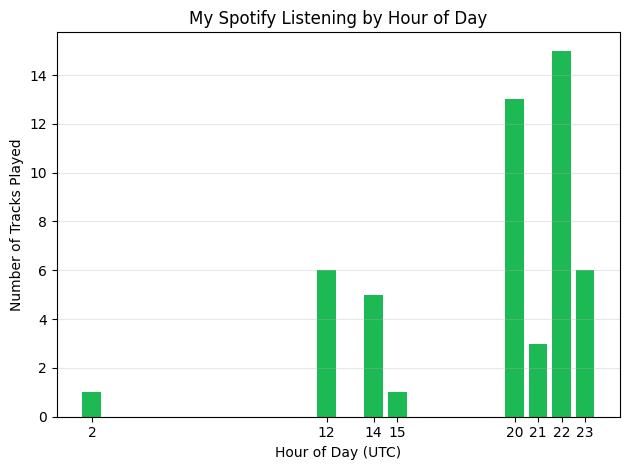

In [6]:
recently_played = sp.current_user_recently_played(limit=50)

print("\n--- Recent Listening --\n")
for i, track in enumerate(recently_played['items'], 1):
    print(f"{i}. {track['track']['artists'][0]['name']}, played at: {track['played_at']}")

recents_hr = []

for i, track in enumerate(recently_played['items'], 1):
    timestamp = track['played_at']
    try:
        dt = datetime.strptime(timestamp, "%Y-%m-%dT%H:%M:%S.%fZ")
    except ValueError:
        dt = datetime.strptime(timestamp, "%Y-%m-%dT%H:%M:%SZ")
    recents_hr.append(dt.hour)


df = pd.DataFrame({'hour': recents_hr})
hour_counts = df['hour'].value_counts().sort_index()

plt.bar(hour_counts.index, hour_counts.values)
plt.title('My Spotify Listening by Hour of Day')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Tracks Played')
plt.xticks(hour_counts.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.bar(hour_counts.index, hour_counts.values, color='#1DB954')
plt.show()

## 3. Short Term vs Long Term Taste
Comparing my top 20 artists over the last 4 weeks vs all time to see what's changed.

In [8]:
long_term_artists = sp.current_user_top_artists(limit=20, time_range="long_term")
short_term_artists = sp.current_user_top_artists(limit=20, time_range="short_term")

long_term_names = []
short_term_names = []

for i, artist in enumerate(long_term_artists['items'], 1):
    long_term_names.append(artist['name'])


for i, artist in enumerate(short_term_artists['items'], 1):
    short_term_names.append(artist['name'])


long_term_set = set(long_term_names)
short_term_set = set(short_term_names)


in_both = long_term_set & short_term_set
new_favs = short_term_set - long_term_set
fallen_off = long_term_set - short_term_set

print("\n--- Consistent Favorite Artists ---\n")
for i, artist in enumerate(sorted(in_both), 1):
    print(f"{i}. {artist}")

print("\n--- New Favorite Artists ---\n")
for i, artist in enumerate(sorted(new_favs), 1):
    print(f"{i}. {artist}")

print("\n--- Old Favorites ---\n")
for i, artist in enumerate(sorted(fallen_off), 1):
    print(f"{i}. {artist}")


--- Consistent Favorite Artists ---

1. All Time Low
2. Childish Gambino
3. Drake
4. Future
5. J. Cole
6. Kanye West
7. Lil Uzi Vert
8. Lil Wayne
9. Mac Miller
10. Pierce The Veil
11. RÜFÜS DU SOL
12. Travis Scott

--- New Favorite Artists ---

1. A Boogie Wit da Hoodie
2. Bad Bunny
3. Bas
4. Frank Ocean
5. Joey Bada$$
6. Linkin Park
7. Paramore
8. Prospa

--- Old Favorites ---

1. A$AP Rocky
2. Fred again..
3. Green Day
4. Hans Zimmer
5. Kendrick Lamar
6. Neck Deep
7. Ramin Djawadi
8. blink-182


## Key Findings

- **Total top artists analyzed:** 20 long term, 20 short term
- **Consistent favorites:** 12 artists appear in both lists, anchored by Drake, J. Cole, and Travis Scott on the hip hop side and All Time Low and Pierce The Veil on the alternative side
- **New obsessions:** 8 artists have entered my recent rotation including Linkin Park, Paramore, and Frank Ocean
- **Fallen off:** 8 artists including Kendrick Lamar, A$AP Rocky, and Green Day have dropped out of recent listening
- **Peak listening hour:** 8pm UTC (4pm Eastern) with heavy evening listening from 3pm–10pm

## Tools & Methods
- Spotify Web API via Spotipy
- Pandas for data aggregation
- Matplotlib for visualization
- Python sets for artist comparison logic